# Arabic Sign Language (ArSL) Letter Recognition
### AI for Lebanon - Education & Accessibility Project

**Goal:** Train a CNN to classify images of Arabic Sign Language (ArSL) alphabet hand signs into one of 32 letter classes. This will power an accessibility/learning tool for deaf and hard-of-hearing students learning or practicing Arabic Sign Language.

**Dataset:** ArASL2018 - 54,049 labeled grayscale (64×64) images across 32 Arabic sign language letters, collected from 40 participants (Latif et al., 2019). Publicly available via Mendeley Data.

**Pipeline overview:**
1. Load and explore the dataset
2. Split into train / validation / test sets (stratified)
3. Build a tf.data pipeline with augmentation
4. Define and train a CNN baseline
5. Evaluate: accuracy, per-class metrics, confusion matrix
6. Visualize predictions
7. Save the trained model
8. (Extension) Ideas for going further


## 1. Setup & Imports

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Configuration

In [20]:
DATA_DIR = "ArASL_Database_54K_Final/ArASL_Database_54K_Final"  

IMG_SIZE = 64          # dataset images are already 64x64 grayscale
BATCH_SIZE = 64
EPOCHS = 15
NUM_CHANNELS = 1        # grayscale

assert os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}. Update the path above."
print("Classes found:", len(os.listdir(DATA_DIR)))


Classes found: 32


## 3. Build a File Index & Explore Class Distribution

In [5]:
records = []
for cls in sorted(os.listdir(DATA_DIR)):
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        records.append({"path": os.path.join(cls_dir, fname), "label": cls})

df = pd.DataFrame(records)
print("Total images:", len(df))
print("Total classes:", df['label'].nunique())
df.head()


Total images: 54049
Total classes: 32


,path,label
0,ArASL_Database_54K_Final/ArASL_Database_54K_Fi...,ain
1,ArASL_Database_54K_Final/ArASL_Database_54K_Fi...,ain
2,ArASL_Database_54K_Final/ArASL_Database_54K_Fi...,ain
3,ArASL_Database_54K_Final/ArASL_Database_54K_Fi...,ain
4,ArASL_Database_54K_Final/ArASL_Database_54K_Fi...,ain


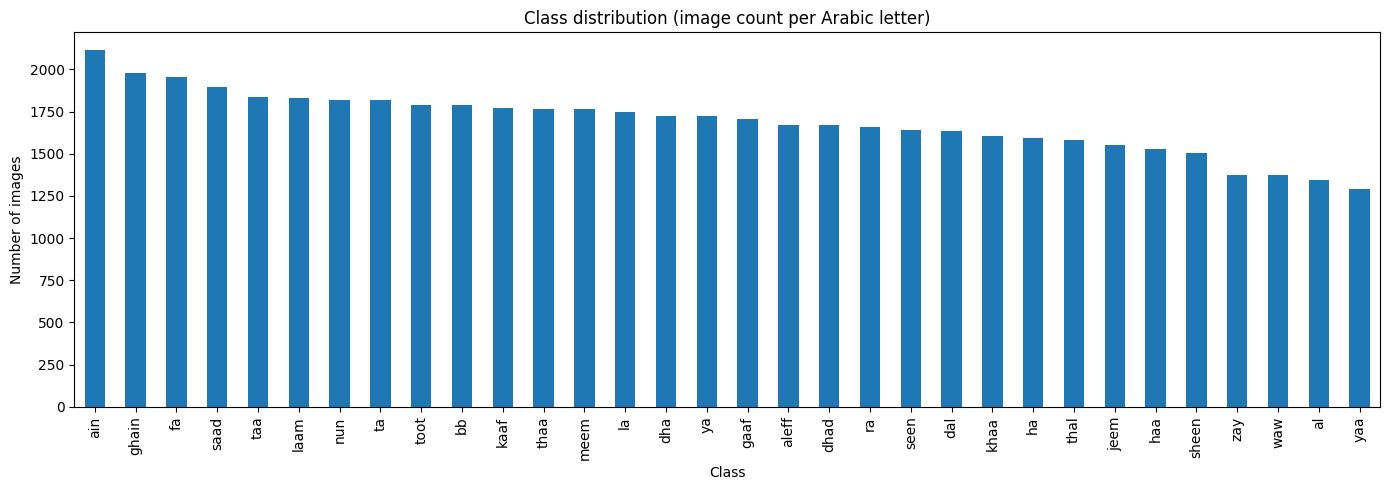

In [6]:
plt.figure(figsize=(14, 5))
df['label'].value_counts().plot(kind='bar')
plt.title("Class distribution (image count per Arabic letter)")
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.tight_layout()
plt.show()


## 4. Train / Validation / Test Split

We use a stratified split so every class is proportionally represented in each set:
- 70% train
- 15% validation
- 15% test


In [7]:
classes = sorted(df['label'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df['label_idx'] = df['label'].map(class_to_idx)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label_idx'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label_idx'], random_state=SEED
)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))


Train: 37834  Val: 8107  Test: 8108


## 5. Handle Class Imbalance

The dataset has mild class imbalance (~1,293 to ~2,114 images per class).
We compute class weights so the loss function penalizes mistakes on
under-represented classes more heavily.


In [8]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(classes)),
    y=train_df['label_idx'].values
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weight range:", min(class_weight_dict.values()), "-", max(class_weight_dict.values()))


Class weight range: 0.7988597972972973 - 1.3064226519337017


## 6. Build the `tf.data` Input Pipeline (with augmentation on train set)

In [9]:
def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=NUM_CHANNELS, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    return img, label

def make_dataset(df, shuffle=False, augment_data=False, batch_size=BATCH_SIZE):
    paths = df['path'].values
    labels = df['label_idx'].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True, augment_data=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)


## 7. Visualize a Few Training Samples

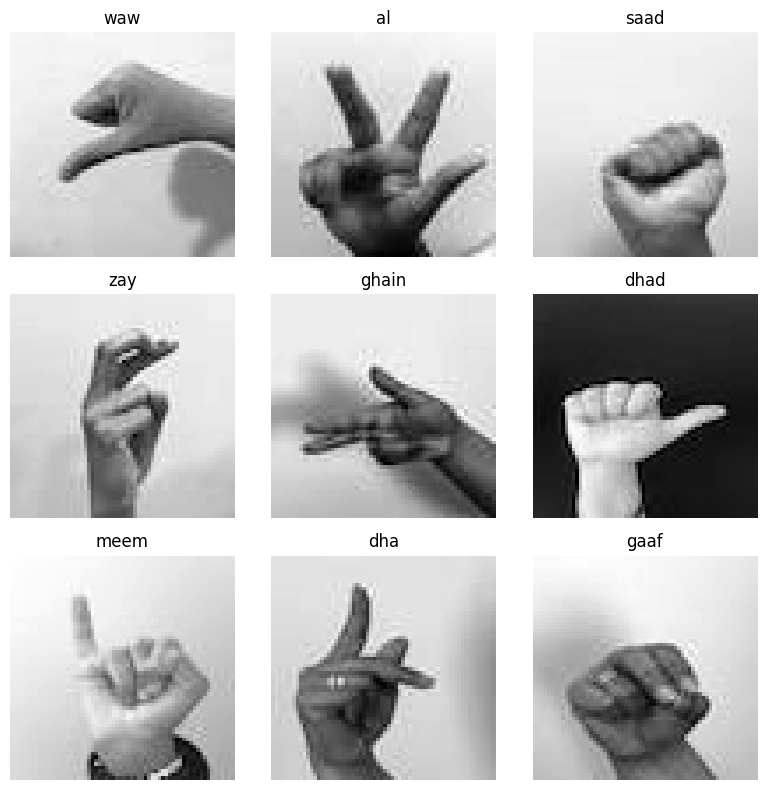

In [10]:
sample_df = train_df.sample(9, random_state=SEED)
plt.figure(figsize=(8, 8))
for i, (_, row) in enumerate(sample_df.iterrows()):
    img = tf.io.read_file(row['path'])
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img.numpy().squeeze(), cmap='gray')
    plt.title(row['label'])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 8. Define the CNN Model

A simple, fast-to-train CNN baseline: three convolutional blocks
followed by dense layers with dropout for regularization.


In [11]:
num_classes = len(classes)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS)),

    tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(num_classes, activation='softmax'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           8,224 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,199,200 (8.39 MB)

 Trainable params: 2,198,752 (8.39 MB)

 Non-trainable params: 448 (1.75 KB)

## 9. Train

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor='val_loss'),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)


Epoch 1/15


C:\Users\leaak\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


592/592 ━━━━━━━━━━━━━━━━━━━━ 262s 432ms/step - accuracy: 0.1192 - loss: 3.0583 - val_accuracy: 0.1449 - val_loss: 2.7696 - learning_rate: 0.0010
Epoch 2/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 165s 278ms/step - accuracy: 0.3631 - loss: 1.9309 - val_accuracy: 0.4018 - val_loss: 1.8064 - learning_rate: 0.0010
Epoch 3/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 166s 279ms/step - accuracy: 0.5721 - loss: 1.2288 - val_accuracy: 0.7619 - val_loss: 0.7425 - learning_rate: 0.0010
Epoch 4/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 170s 287ms/step - accuracy: 0.7097 - loss: 0.8308 - val_accuracy: 0.4413 - val_loss: 1.8781 - learning_rate: 0.0010
Epoch 5/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 163s 275ms/step - accuracy: 0.7894 - loss: 0.6114 - val_accuracy: 0.5832 - val_loss: 2.0588 - learning_rate: 0.0010
Epoch 6/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 160s 269ms/step - accuracy: 0.8653 - loss: 0.3993 - val_accuracy: 0.9550 - val_loss: 0.1740 - learning_rate: 5.0000e-04
Epoch 7/15
592/592 ━━━━━━━━━━━━━━━━━━━━ 158s 267ms/step - accuracy: 0.8

## 10. Training Curves

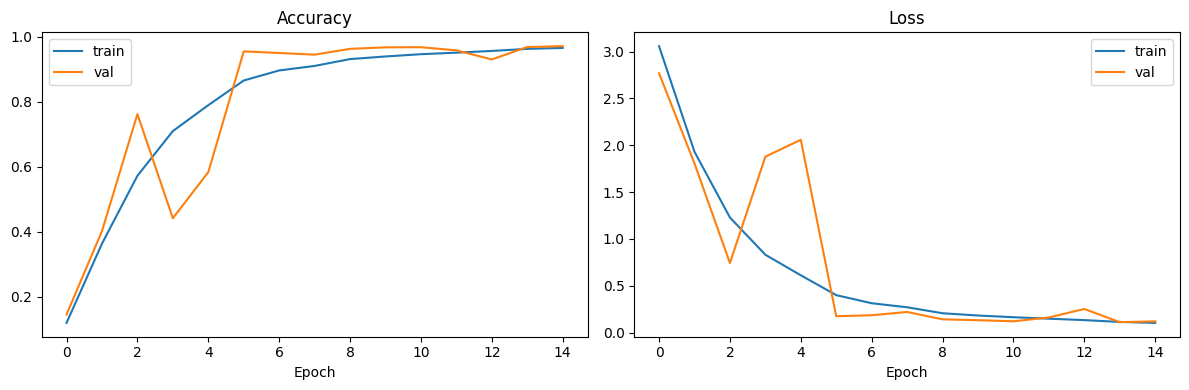

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Evaluate on the Held-Out Test Set

In [14]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")


Test accuracy: 0.9678
Test loss: 0.1403


In [15]:
# Get predictions for classification report + confusion matrix
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=classes, digits=3))


              precision    recall  f1-score   support

         ain      0.991     0.991     0.991       317
          al      0.980     0.985     0.983       201
       aleff      0.988     0.976     0.982       251
          bb      0.963     0.978     0.970       269
         dal      0.963     0.959     0.961       245
         dha      0.956     0.919     0.937       259
        dhad      0.976     0.980     0.978       250
          fa      0.933     0.946     0.939       294
        gaaf      0.927     0.941     0.934       255
       ghain      0.980     0.983     0.982       297
          ha      0.979     0.954     0.966       239
         haa      0.969     0.969     0.969       229
        jeem      0.938     0.974     0.956       233
        kaaf      0.977     0.974     0.976       266
        khaa      0.975     0.971     0.973       241
          la      0.992     0.973     0.983       262
        laam      0.968     0.978     0.973       275
        meem      0.989    

## 12. Confusion Matrix

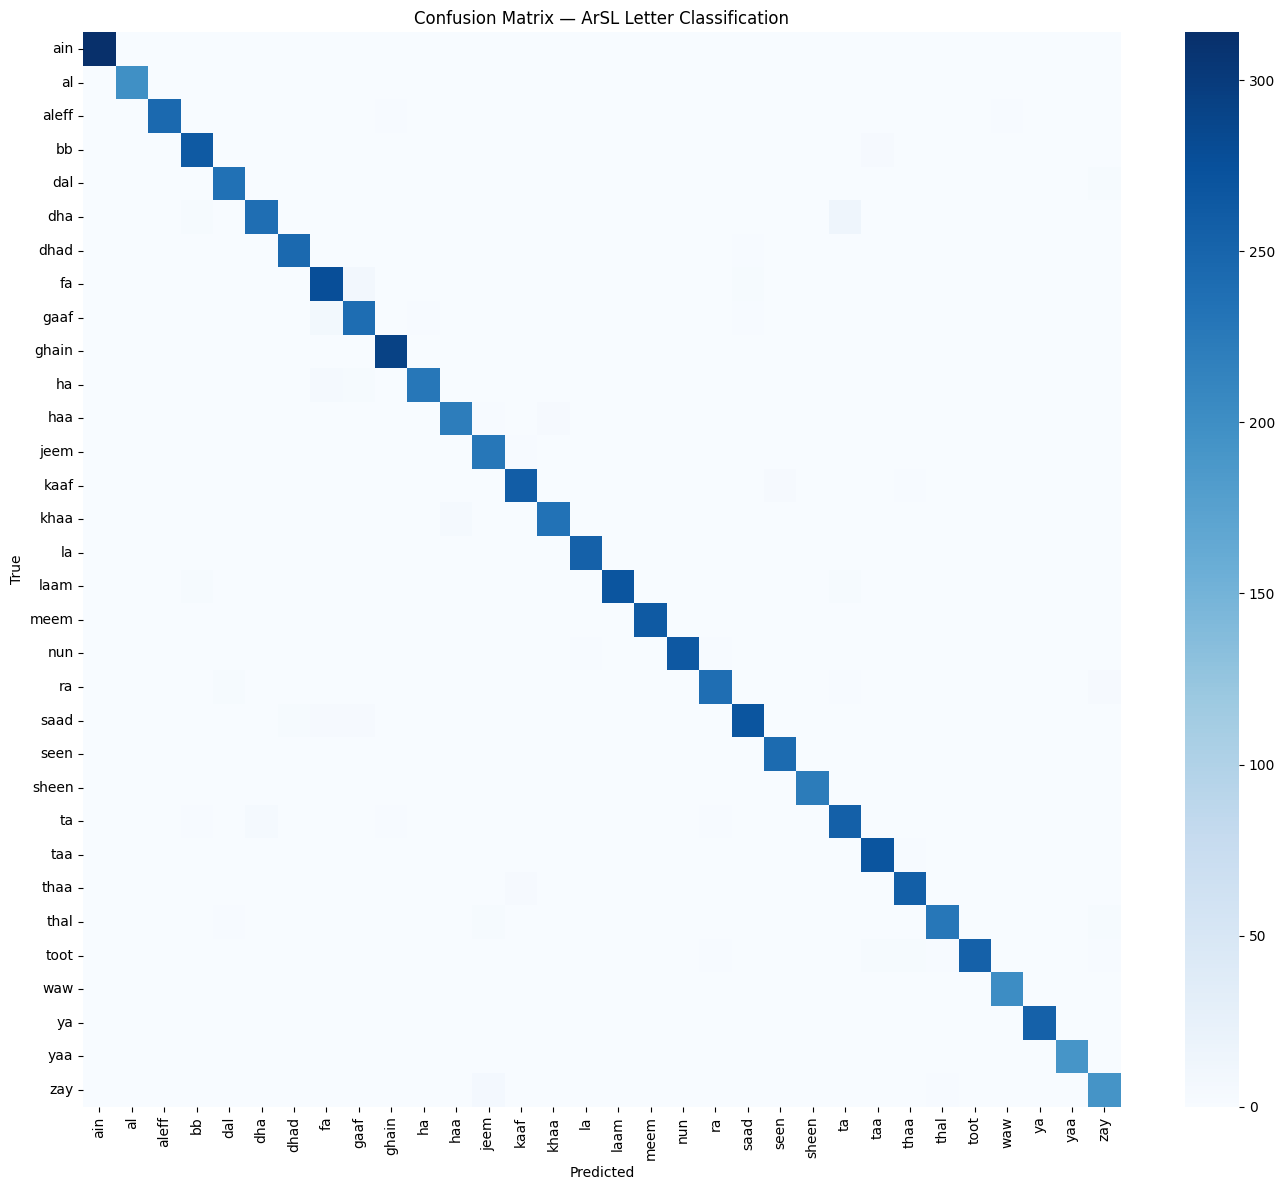

In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — ArSL Letter Classification')
plt.tight_layout()
plt.show()


## 13. Visualize Sample Predictions (correct & incorrect)

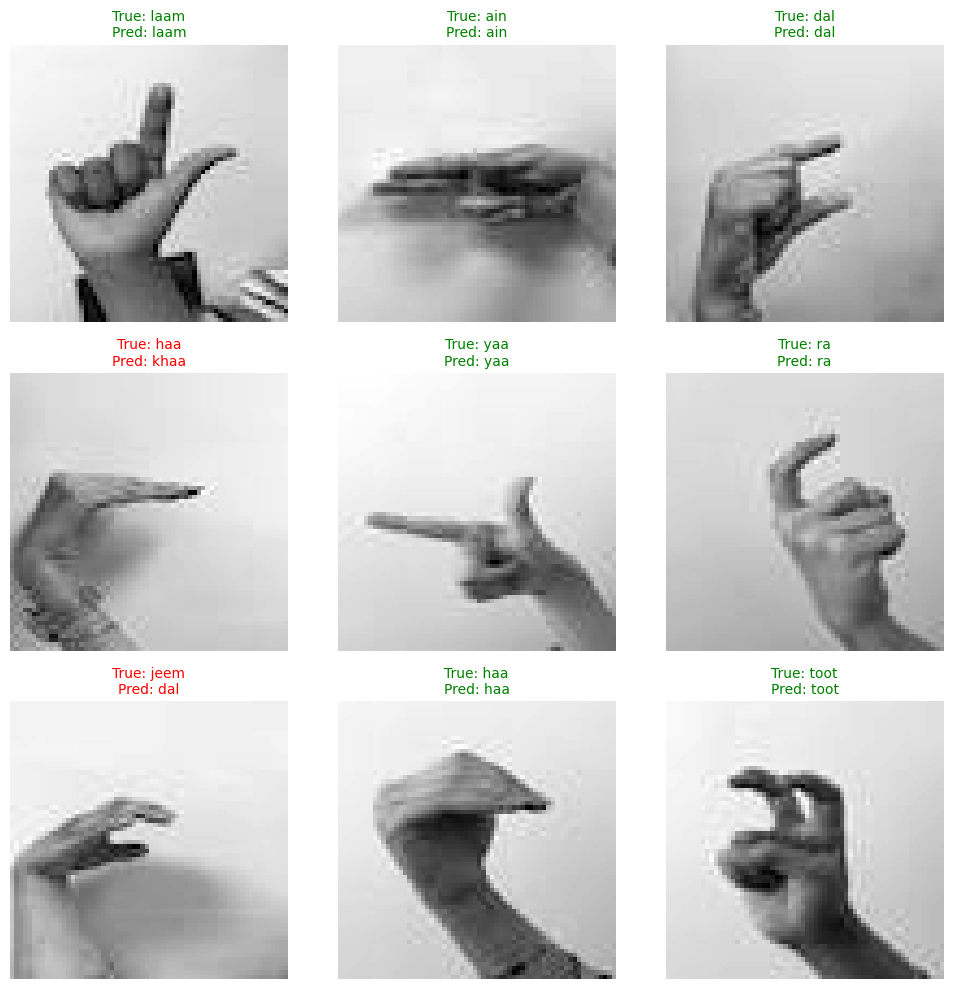

In [17]:
plt.figure(figsize=(10, 10))
sample_test = test_df.sample(9, random_state=1)

for i, (_, row) in enumerate(sample_test.iterrows()):
    img_raw = tf.io.read_file(row['path'])
    img = tf.image.decode_image(img_raw, channels=1, expand_animations=False)
    img_resized = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_norm = tf.cast(img_resized, tf.float32) / 255.0
    pred = model.predict(tf.expand_dims(img_norm, 0), verbose=0)
    pred_label = idx_to_class[np.argmax(pred)]
    true_label = row['label']

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.numpy().squeeze(), cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


## 14. Save the Trained Model

In [21]:
model.save("arsl_cnn_model.keras")
print("Model saved to arsl_cnn_model.keras")


Model saved to arsl_cnn_model.keras


## 15. Conclusion

After training, this model is 2.2 million numbers arranged into filters and weights. gradient descent, repeated thousands of times, gradually shaped those numbers into filters that respond to edges, then finger-shapes, then whole hand-silhouettes, and a final decision layer mapping those silhouettes to 32 labels.

This is why real-world deployment (through a live webcam) is a g different challenge from offline evaluation. Any input that doesn't resemble those patterns closely enough (different lighting, skin color, a mirrored hand, a stretched/distorted crop, background clutter, etc...) falls outside what the model actually learned, even though (to a human) it's obviously the same letter. That's the root of the "domain gap" between test-set accuracy and live performance.